In [2]:
import os
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [3]:
! pwd
! ls -l ../Data/cell-line-level/pre-inj

/Users/alyulina/Projects/Cancer/Code
total 242128
-rw-r--r--  1 alyulina  staff  29769676 May 25 14:11 SK1_61_clID_bc_extracted.txt
-rw-r--r--  1 alyulina  staff    180317 May 25 14:11 SK1_61_failed_clIDs.txt
-rw-r--r--  1 alyulina  staff       160 May 25 14:11 SK1_61_find_barcodes_stats.txt
-rw-r--r--  1 alyulina  staff  52249746 May 25 14:11 SK1_62_clID_bc_extracted.txt
-rw-r--r--  1 alyulina  staff    305316 May 25 14:11 SK1_62_failed_clIDs.txt
-rw-r--r--  1 alyulina  staff       162 May 25 14:11 SK1_62_find_barcodes_stats.txt
-rw-r--r--  1 alyulina  staff  38938226 May 25 14:11 SK1_63_clID_bc_extracted.txt
-rw-r--r--  1 alyulina  staff    224098 May 25 14:11 SK1_63_failed_clIDs.txt
-rw-r--r--  1 alyulina  staff       161 May 25 14:11 SK1_63_find_barcodes_stats.txt


In [37]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins
# clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']

# cell lines w/o spike-ins; added numbers (1 and 2) to cell lines w/ identical names
# cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

In [79]:
pre_inj_cell_line_counts = {} # cell line counts in each sample
pre_inj_coverage = {} # coverage of each sample

for i in samples_pre_inj:
    
    with open('../Data/cell-line-level/pre-inj/' + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    pre_inj_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    pre_inj_coverage[i] = sum(pre_inj_cell_line_counts[i].values())

In [80]:
in_vitro_cell_line_counts = {} # cell line counts in each sample
in_vitro_coverage = {} # coverage of each sample

for i in samples_in_vitro:
    
    with open('../Data/cell-line-level/in-vitro/' + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    in_vitro_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    in_vitro_coverage[i] = sum(in_vitro_cell_line_counts[i].values())

In [81]:
# making time series points for each cell line:
# to get fractions, need to know the total count at that timepoint in a sample 

ts = {1: [64, 65, 66], 
      2: [67, 68, 69],
      3: [70, 71, 72],
      4: [73, 74, 75],
      5: [76, 77, 78],
      6: [79, 80, 81],
      7: [82, 83, 84],
      8: [85, 86, 87]}

cell_line_fracs_t = {}

for i in clIDs:
    cell_line_fracs_t[i] = {}
    
    cell_line_fracs_t[i][0] = []
    for j in samples_pre_inj:
        cell_line_fracs_t[i][0].append(pre_inj_cell_line_counts[j][i] / pre_inj_coverage[j])
        
    for t in range(1, 9):
        cell_line_fracs_t[i][t] = []
        
        for j in ['SK1_' + str(x) for x in ts[t]]:
            cell_line_fracs_t[i][t].append(in_vitro_cell_line_counts[j][i] / in_vitro_coverage[j])


In [108]:
# ordering by the highest avg. count at the last time point relative to the pre-inj.

tmp = []
for i in clIDs:
    tmp.append([i, np.mean([x / np.mean(cell_line_fracs_t[i][0]) for x in cell_line_fracs_t[i][8]])])
    
clIDs_ordered = [x[0] for x in sorted(tmp, key = lambda x: x[-1], reverse=True)]

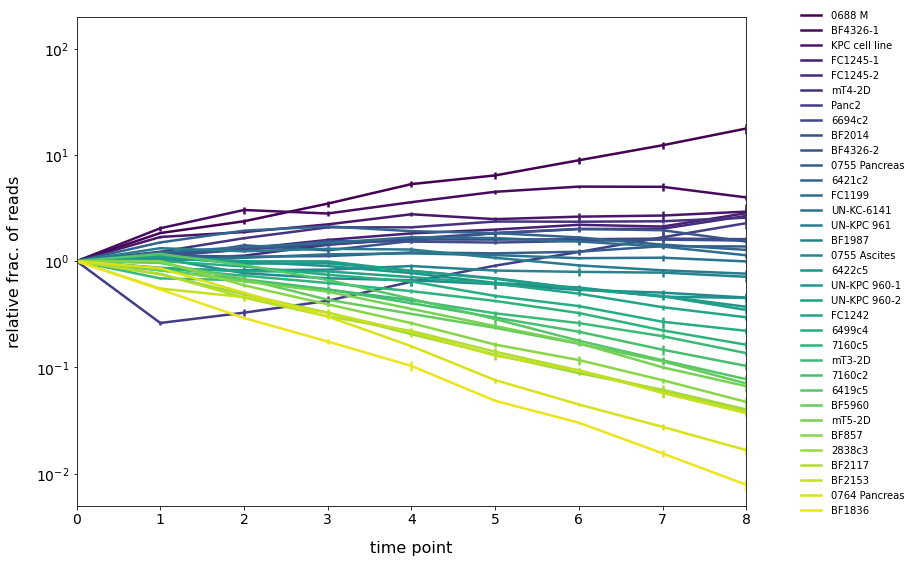

In [240]:
plt.figure(figsize=(12, 9));

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
data = []
data_t0 = []

for count, i in enumerate(clIDs_ordered):
    
    ys = [1] + [np.mean([y / np.mean(cell_line_fracs_t[i][0]) for y in cell_line_fracs_t[i][x]]) for x in range(1, 9)]
    errs = [0] + [np.std([y / np.mean(cell_line_fracs_t[i][0]) for y in cell_line_fracs_t[i][x]]) for x in range(1, 9)]
    
    plt.errorbar(range(0, 9), ys, errs, linewidth=2.5, color=viridis.to_rgba(count))
    
    # for legend
    plt.plot([0, 0], [0, 0], linewidth=2.5, color=viridis.to_rgba(count), label=clID_dict[i].replace('_', ' '))
    
    data.append([i, ys, errs])
    data_t0.append([i, np.mean(cell_line_fracs_t[i][0])])

plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(0, 8)

plt.yticks([1e-2, 1e-1, 1e0, 1e1, 1e2], [1e-2, 1e-1, 1e0, 1e1, 1e2], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-3, 2e2)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frac. of reads', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.03)); 

# plt.savefig('../Data/cell-line-level/in_vitro_t.png', dpi=300, bbox_inches='tight')    

# saving output:

# with open('../Data/cell-line-level/in-vitro_t_data.txt', 'w+') as o:
#     o.writelines(['clID\tmean, std at t=1\tmean, std at t=2\tmean, std at t=3\tmean, std at t=4\tmean, std at t=5\tmean, std at t=6\tmean, std at t=7\tmean, std at t=8\n'] + 
#                  [data[l][0] + '\t' + '\t'.join([', '.join(list(map(str, x))) for x in list(zip(data[l][1][1:], data[l][2][1:]))]) + '\n' for l in range(len(data))])

# with open('../Data/cell-line-level/in-vitro_t0_data.txt', 'w+') as o:
#     o.writelines(['clID\tavg. frac. at t=0'] + 
#                  [str(x[0]) + '\t' + str(x[1]) + '\n' for x in data_t0])

    

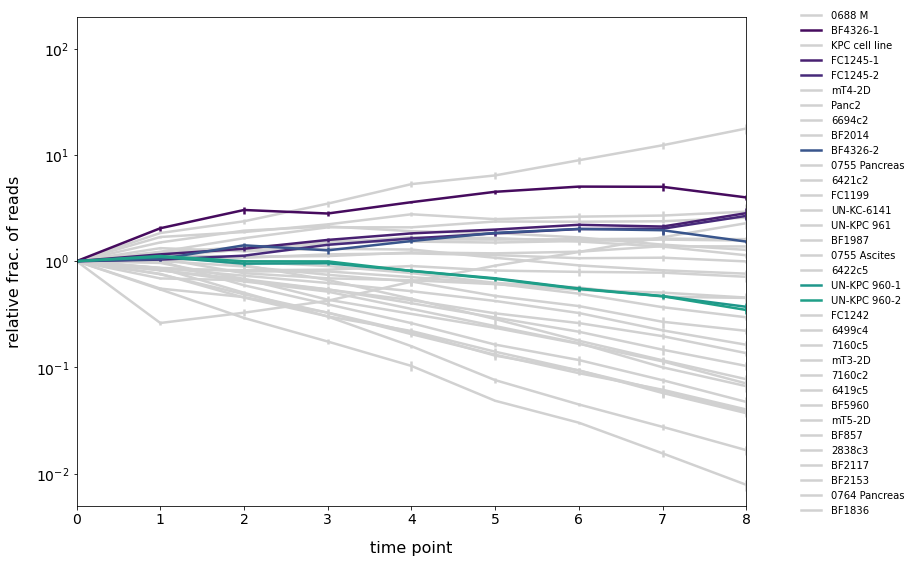

In [208]:
plt.figure(figsize=(12, 9));

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))

for count, i in enumerate(clIDs_ordered):
    
    if clID_dict[i] in ['FC1245-1', 'FC1245-2', 'BF4326-1', 'BF4326-2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        c = viridis.to_rgba(count)
        z = 2
    else:
        c = '#d1d1d1'
        z = 1
 
    ys = [1] + [np.mean([y / np.mean(cell_line_fracs_t[i][0]) for y in cell_line_fracs_t[i][x]]) for x in range(1, 9)]
    errs = [0] + [np.std([y / np.mean(cell_line_fracs_t[i][0]) for y in cell_line_fracs_t[i][x]]) for x in range(1, 9)]
    
    plt.errorbar(range(0, 9), ys, errs, linewidth=2.5, color=c, zorder=z)
    
    # for legend
    plt.plot([0, 0], [0, 0], linewidth=2.5, color=c, label=clID_dict[i].replace('_', ' '))
    

plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(0, 8)

plt.yticks([1e-2, 1e-1, 1e0, 1e1, 1e2], [1e-2, 1e-1, 1e0, 1e1, 1e2], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-3, 2e2)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frac. of reads', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.03)); 

# plt.savefig('../Data/cell-line-level/in_vitro_t_grey.png', dpi=300, bbox_inches='tight')
    

In [246]:
# ordering by the highest avg. count at the last time point relative to the t=1

tmp = []
for i in clIDs:
    tmp.append([i, np.mean([x / np.mean(cell_line_fracs_t[i][1]) for x in cell_line_fracs_t[i][8]])])
    
clIDs_ordered = [x[0] for x in sorted(tmp, key = lambda x: x[-1], reverse=True)]

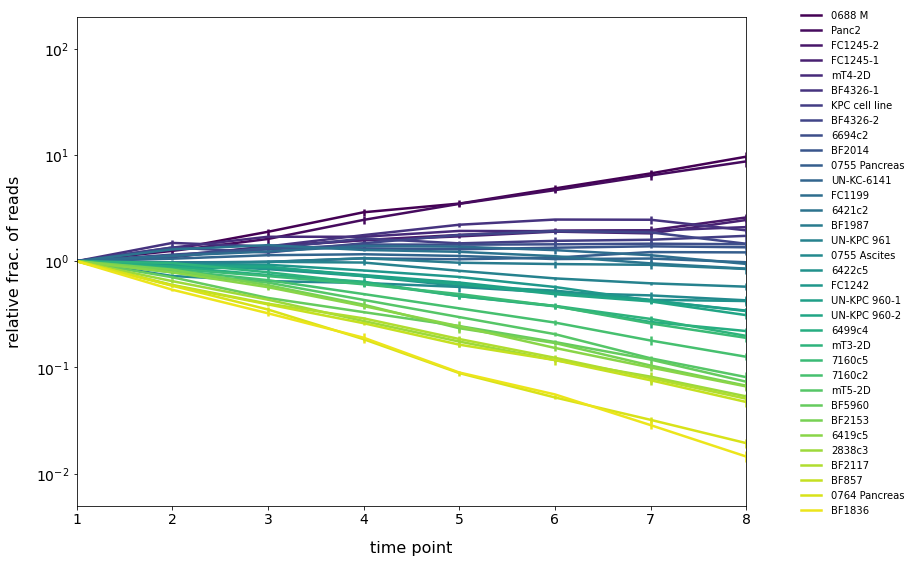

In [248]:
plt.figure(figsize=(12, 9));

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
#data = []
#data_t0 = []

for count, i in enumerate(clIDs_ordered):
    
    ys = [1] + [np.mean([y / np.mean(cell_line_fracs_t[i][1]) for y in cell_line_fracs_t[i][x]]) for x in range(2, 9)]
    errs = [0] + [np.std([y / np.mean(cell_line_fracs_t[i][1]) for y in cell_line_fracs_t[i][x]]) for x in range(2, 9)]
    
    plt.errorbar(range(1, 9), ys, errs, linewidth=2.5, color=viridis.to_rgba(count))
    
    # for legend
    plt.plot([0, 0], [0, 0], linewidth=2.5, color=viridis.to_rgba(count), label=clID_dict[i].replace('_', ' '))
    
    #data.append([i, ys, errs])
    #data_t0.append([i, np.mean(cell_line_fracs_t[i][0])])

plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(1, 8)

plt.yticks([1e-2, 1e-1, 1e0, 1e1, 1e2], [1e-2, 1e-1, 1e0, 1e1, 1e2], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-3, 2e2)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frac. of reads', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.03)); 

# plt.savefig('../Data/cell-line-level/in_vitro_t_norm_to_t=1.png', dpi=300, bbox_inches='tight')    
    

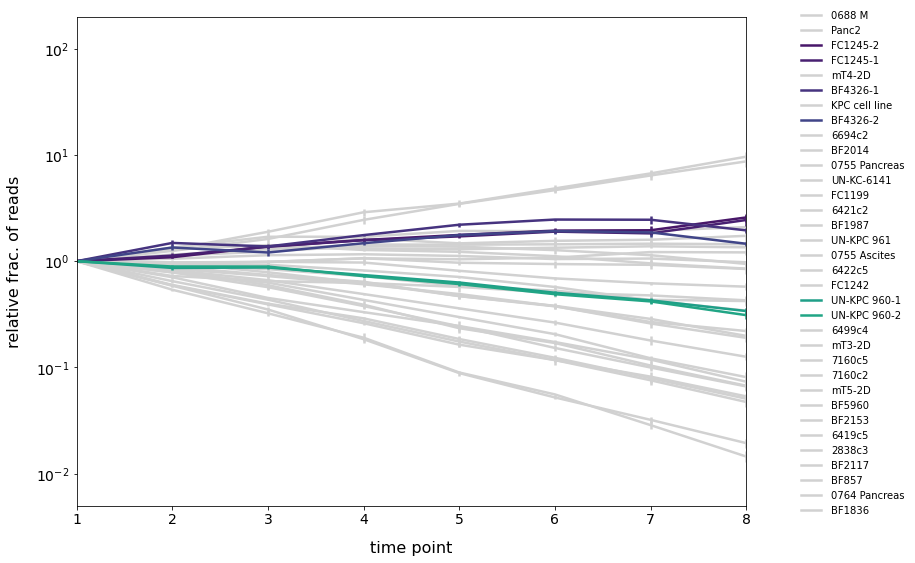

In [250]:
plt.figure(figsize=(12, 9));

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))
#data = []
#data_t0 = []

for count, i in enumerate(clIDs_ordered):
    
    if clID_dict[i] in ['FC1245-1', 'FC1245-2', 'BF4326-1', 'BF4326-2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        c = viridis.to_rgba(count)
        z = 2
    else:
        c = '#d1d1d1'
        z = 1
    
    ys = [1] + [np.mean([y / np.mean(cell_line_fracs_t[i][1]) for y in cell_line_fracs_t[i][x]]) for x in range(2, 9)]
    errs = [0] + [np.std([y / np.mean(cell_line_fracs_t[i][1]) for y in cell_line_fracs_t[i][x]]) for x in range(2, 9)]
    
    plt.errorbar(range(1, 9), ys, errs, linewidth=2.5, color=c, zorder=z)
    
    # for legend
    plt.plot([0, 0], [0, 0], linewidth=2.5, color=c, label=clID_dict[i].replace('_', ' '))
    
    #data.append([i, ys, errs])
    #data_t0.append([i, np.mean(cell_line_fracs_t[i][0])])

plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], size=14)
plt.xlim(1, 8)

plt.yticks([1e-2, 1e-1, 1e0, 1e1, 1e2], [1e-2, 1e-1, 1e0, 1e1, 1e2], size=14)
plt.yscale('log'); plt.minorticks_off();
plt.ylim(5e-3, 2e2)

plt.xlabel('time point', fontsize=16, labelpad=14);
plt.ylabel('relative frac. of reads', fontsize=16, labelpad=14);

# plt.title('in vitro', size=16, pad=14)
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.03)); 

# plt.savefig('../Data/cell-line-level/in_vitro_t_norm_to_t=1_grey.png', dpi=300, bbox_inches='tight')    
   

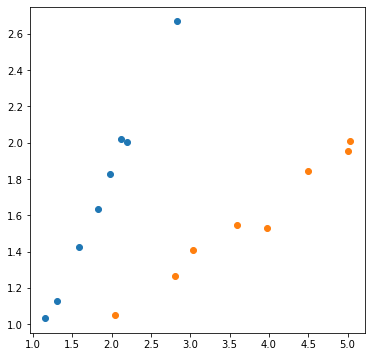

In [233]:
plt.figure(figsize=(6, 6));

plt.scatter([np.mean([y / np.mean(cell_line_fracs_t['AGTC'][0]) for y in cell_line_fracs_t['AGTC'][x]]) for x in range(1, 9)],
           [np.mean([y / np.mean(cell_line_fracs_t['CTTC'][0]) for y in cell_line_fracs_t['CTTC'][x]]) for x in range(1, 9)])


plt.scatter([np.mean([y / np.mean(cell_line_fracs_t['ATCG'][0]) for y in cell_line_fracs_t['ATCG'][x]]) for x in range(1, 9)],
           [np.mean([y / np.mean(cell_line_fracs_t['CACT'][0]) for y in cell_line_fracs_t['CACT'][x]]) for x in range(1, 9)])



In [232]:
cell_line_dict['BF4326-2'] 

'CACT'